# Broadband Beamforming with Delay-and-Sum

This notebook demonstrates the complete passive sonar processing chain:

1. **Broadband continuous signal generation** via STFT
2. **Acoustic propagation** with time-varying transfer functions
3. **Ambient noise modeling** with colored noise
4. **Frequency-domain delay-and-sum beamforming**
5. **CFAR detection** with peak finding

## Wavefront Curvature Effects

This demonstration reveals an important physical phenomenon in passive sonar: **plane-wave beamforming assumptions break down at close range**.

Standard delay-and-sum beamforming assumes incoming acoustic waves are **plane waves** - i.e., wavefronts are parallel across the array aperture. The broadband ray tracing method used herein calculates 3d propagation paths with spherical wavefronts, but the beamformer still assumes plane waves. This decreases the power of the beamformer output when the target is close to the array.


## 1. Import Libraries and Set Random Seed

In [61]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(1999)

from datetime import datetime, timedelta
from scipy.signal import get_window, spectrogram
from stonesoup.models.transition.linear import (
    CombinedLinearGaussianTransitionModel,
    ConstantVelocity,
)
from stonesoup.types.groundtruth import GroundTruthState, GroundTruthPath

from nereus.platform import TowedArrayPlatform
from nereus.models.environment import Linear, FlatBathymetry
from nereus.models.propagation import rtrsAcousticPropagationModel
from nereus.signal.anthropogenic import BroadbandShipSignal
from nereus.signal.ambient import ColouredNoise
from nereus.simulator import BroadbandPassiveSonarArraySimulator
from nereus.sigproc import DelayAndSumBeamformer, SteeringCalculator
from nereus.detector import CFARDetector, PassiveSonarDetector, PeakDetector
from nereus.plotter import BearingsPlotter

print("All libraries imported successfully")

All libraries imported successfully


## 2. Define Simulation Parameters

Configure simulation timing with 90 timesteps at 10-second intervals (15 minutes total).

In [ ]:
SIM_RATE = 10.0
SIM_PARAMS = {
    "start_time": datetime.now().replace(hour=0, minute=0, second=0, microsecond=0),
    "time_interval": timedelta(seconds=SIM_RATE),
    "num_steps": 90,
}

SHIP_PARAMS = {
    "start_vector": np.array([0, 0, 0, 0, -10.0, 0]),  # Stationary platform
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
}

ARRAY_PARAMS = {
    "num_sensors": 100,
    "tow_cable_length": 100.0,
    "sensor_spacing": 0.5,
    "array_depth": -50.0,
}

TARGET_PARAMS = {
    "start_vector": np.array([0.0, 0.0, 2000.0, -5.0, -5.0, 0.0]),
    "position_mapping": [0, 2, 4],
    "velocity_mapping": [1, 3, 5],
    "transition_model": CombinedLinearGaussianTransitionModel(
        [ConstantVelocity(0), ConstantVelocity(0), ConstantVelocity(0)]
    ),
    "amplitudes_upa": 10 ** (np.array([100.0]) / 20),
    "frequencies_hz": np.array([100.0]),
    "phases_rad": np.array([0.0]),
    "tonal_bandwidth_hz": 2.0,
    "noise_amplitude_upa": 10 ** (60 / 20),
    "noise_spectral_exponent": -1.0,
}

total_duration_s = SIM_PARAMS["num_steps"] * SIM_PARAMS["time_interval"].total_seconds()

SIGNAL_PARAMS = {
    "duration_s": total_duration_s,
    "sampling_rate_hz": 500.0,
    "frame_len": 500,
    "hop_factor": 2,
    "fade_in_ms": 1000.0,
}

AMBIENT_NOISE_PARAMS = {
    "amplitude_upa": 10 ** (45.0 / 20),
    "spectral_exponent": -1,
}

PROP_PARAMS = {
    # "ssp": Constant(speed=1500.0),
    "ssp": Linear(surface_speed=1500.0, gradient=0.2),
    # "ssp": Munk(),
    "attenuation_factor": 0.5,
    "bathymetry": FlatBathymetry(depth=-150.0),
    # "bathymetry": FlatBathymetry(depth=-5000.0),
    "step_m": 20.0,
    "azimuth_search_width": 2.0,
    "azimuth_resolution": 0.5,
    "elevation_range": (-25.0, 25.0),
    "elevation_resolution": 1.0,
}

print(f"Total simulation duration: {total_duration_s} seconds")
print(f"Number of timesteps: {SIM_PARAMS['num_steps']}")
print(f"Array: {ARRAY_PARAMS['num_sensors']} sensors at {ARRAY_PARAMS['array_depth']} m depth")
print(f"Target range: {TARGET_PARAMS['start_vector'][2]} m")
print(f"Target frequencies: {TARGET_PARAMS['frequencies_hz']} Hz")

Total simulation duration: 900.0 seconds
Number of timesteps: 90
Array: 100 sensors at -50.0 m depth
Target range: 2000.0 m
Target frequencies: [100.] Hz


## 3. Define Beamforming and Detection Parameters

Configure steering directions, beamformer shading, and CFAR detection thresholds.

In [63]:
# Beamforming parameters
BF_PARAMS = {
    "shading": "blackman",  # Window for spatial tapering
    "domain": "frequency",  # Frequency-domain beamforming
}

# Steering parameters
STEER_PARAMS = {
    "steering_azimuths_rad": np.linspace(-np.pi, np.pi, 181),  # 1 degree resolution
}

# Detection parameters
DET_PARAMS = {
    "cfar_detector": {
        "num_guard_cells": 2,
        "num_training_cells": 5,
        "threshold_factor": 1.5,
    },
    "peak_detector": {
        "distance": 3,  # Minimum peak separation
    },
}

## 4. Create Platform and Target Trajectory

Initialize the towed array platform and generate the moving target trajectory with ground truth bearings.

In [64]:
initial_state = GroundTruthState(SHIP_PARAMS["start_vector"], timestamp=SIM_PARAMS["start_time"])

platform = TowedArrayPlatform(
    states=[initial_state],
    position_mapping=SHIP_PARAMS["position_mapping"],
    velocity_mapping=SHIP_PARAMS["velocity_mapping"],
    transition_models=[SHIP_PARAMS["transition_model"]],
    transition_times=[timedelta(seconds=total_duration_s)],
    num_sensors=ARRAY_PARAMS["num_sensors"],
    cable_length_m=ARRAY_PARAMS["tow_cable_length"],
    sensor_spacing_m=ARRAY_PARAMS["sensor_spacing"],
    array_depth_m=ARRAY_PARAMS["array_depth"],
)

# Move platform through all timesteps
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    platform.move(new_time)


target_states = [
    GroundTruthState(
        TARGET_PARAMS["start_vector"],
        timestamp=SIM_PARAMS["start_time"],
        metadata={
            "amplitudes_upa": TARGET_PARAMS["amplitudes_upa"],
            "frequencies_hz": TARGET_PARAMS["frequencies_hz"],
            "phases_rad": TARGET_PARAMS["phases_rad"],
            "position_mapping": TARGET_PARAMS["position_mapping"],
            "velocity_mapping": TARGET_PARAMS["velocity_mapping"],
        },
    )
]

transition_model = TARGET_PARAMS["transition_model"]
for i in range(1, SIM_PARAMS["num_steps"]):
    new_time = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    time_interval = new_time - target_states[-1].timestamp
    new_state_vector = transition_model.function(
        target_states[-1], noise=False, time_interval=time_interval
    )
    new_state = GroundTruthState(
        new_state_vector,
        timestamp=new_time,
        metadata=target_states[-1].metadata,
    )
    target_states.append(new_state)

target_ground_truth = GroundTruthPath(target_states)


gt_relative_bearings = []

for target_state in target_ground_truth.states:
    platform_state = platform.get_platform_state_at(target_state.timestamp)
    ref_sensor_position = np.mean(platform_state.array.state_vector, axis=1)
    target_pos = np.array([target_state.state_vector[0], target_state.state_vector[2]])
    relative_pos = target_pos - ref_sensor_position[:2]
    bearing_rad = np.arctan2(relative_pos[1], relative_pos[0])
    gt_relative_bearings.append(bearing_rad)

gt_relative_bearings = np.array(gt_relative_bearings)

# Create GroundTruthPath for bearings
relative_bearing_truth_states = []
for i, bearing in enumerate(gt_relative_bearings):
    timestamp = SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    bearing_state = GroundTruthState(state_vector=np.array([bearing]), timestamp=timestamp)
    relative_bearing_truth_states.append(bearing_state)

relative_bearing_ground_truth = GroundTruthPath(relative_bearing_truth_states)

## 5. Create Signal, Propagation, and Noise Models

Set up the broadband ship signal model, rtrs acoustic propagation, and colored ambient noise.

In [ ]:
signal_model = BroadbandShipSignal(
    duration_s=SIGNAL_PARAMS["duration_s"],
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    frame_len=SIGNAL_PARAMS["frame_len"],
    hop_factor=SIGNAL_PARAMS["hop_factor"],
    tonal_bandwidth_hz=TARGET_PARAMS["tonal_bandwidth_hz"],
    noise_amplitude_upa=TARGET_PARAMS["noise_amplitude_upa"],
    noise_spectral_exponent=TARGET_PARAMS["noise_spectral_exponent"],
    noise_freq_range_hz=(0.0, SIGNAL_PARAMS["sampling_rate_hz"] / 2),
    tonal_noise_is_constant=True,
    noise_is_constant=True,
)

prop_model = rtrsAcousticPropagationModel(
    ssp=PROP_PARAMS["ssp"],
    bathymetry=PROP_PARAMS["bathymetry"],
    step_m=PROP_PARAMS["step_m"],
    azimuth_search_width=PROP_PARAMS["azimuth_search_width"],
    azimuth_resolution=PROP_PARAMS["azimuth_resolution"],
    elevation_range=PROP_PARAMS["elevation_range"],
    elevation_resolution=PROP_PARAMS["elevation_resolution"],
)

noise_model = ColouredNoise(
    amplitude_upa=AMBIENT_NOISE_PARAMS["amplitude_upa"],
    spectral_exponent=AMBIENT_NOISE_PARAMS["spectral_exponent"],
    duration_s=SIM_PARAMS["time_interval"].total_seconds(),
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
)

## 6. Create Beamformer and Steering Calculator

Initialize the delay-and-sum beamformer with Blackman shading and the steering vector calculator.

In [66]:
das_beamformer = DelayAndSumBeamformer(
    sampling_rate_hz=SIGNAL_PARAMS["sampling_rate_hz"],
    shading=get_window(BF_PARAMS["shading"], platform.num_sensors),
    domain=BF_PARAMS["domain"],
)

steering_calculator = SteeringCalculator(
    ssp=PROP_PARAMS["ssp"],
    steering_azimuths_rad=STEER_PARAMS["steering_azimuths_rad"],
)

## 7. Create Broadband Simulator with Beamforming

Initialize the simulator that combines signal generation, propagation, noise, and beamforming.

In [67]:
simulator = BroadbandPassiveSonarArraySimulator(
    platform=platform,
    propagation_model=prop_model,
    signal_models=[signal_model],
    noise_model=noise_model,
    beamformer=das_beamformer,
    steering_calculator=steering_calculator,
    ground_truth_paths=[target_ground_truth],
    fade_in_ms=SIGNAL_PARAMS["fade_in_ms"],
)

## 8. Run Simulation with Detection Chain

Execute the simulation with CFAR detection and peak finding. This step processes all timesteps and may take several minutes.

**Note**: This is a computationally intensive operation due to beamforming across 361 steering directions for 90 timesteps.

In [68]:
data_generator = simulator.sensor_data_gen()

# Create detection chain
cfar_detector = CFARDetector(
    num_guard_cells=DET_PARAMS["cfar_detector"]["num_guard_cells"],
    num_training_cells=DET_PARAMS["cfar_detector"]["num_training_cells"],
    threshold_factor=DET_PARAMS["cfar_detector"]["threshold_factor"],
)
peak_detector = PeakDetector(distance=DET_PARAMS["peak_detector"]["distance"])

detection_chain = [cfar_detector, peak_detector]

detector = PassiveSonarDetector(
    detection_chain=detection_chain,
    sensor_data_gen=data_generator,
    steering_azimuths_rad=STEER_PARAMS["steering_azimuths_rad"],
)

# Run detection
all_detections = list(detector.detections_gen(progress_bar=True))
snr_map = detector.snr_history

Generating Detections: 90it [00:19,  4.57it/s]


In [69]:
# Prepare data for plotting
timesteps = [
    SIM_PARAMS["start_time"] + i * SIM_PARAMS["time_interval"]
    for i in range(SIM_PARAMS["num_steps"])
]

detections_for_plotter = [detection_set for _, detection_set in all_detections]

# Initialize plotter
style_guide = {"figure": {"figsize": (4, 4), "font_size": 10}}
plotter = BearingsPlotter(style_guide=style_guide, bearing_range_deg=(-180, 180))

## 9. Visualize Beamformer Output with Detections

Plot the SNR map over time and bearing, showing raw beamformer output and detected peaks with ground truth overlay.

Text(0.5, 1.02, 'Broadband Beamforming Demo - 100 Sensors')

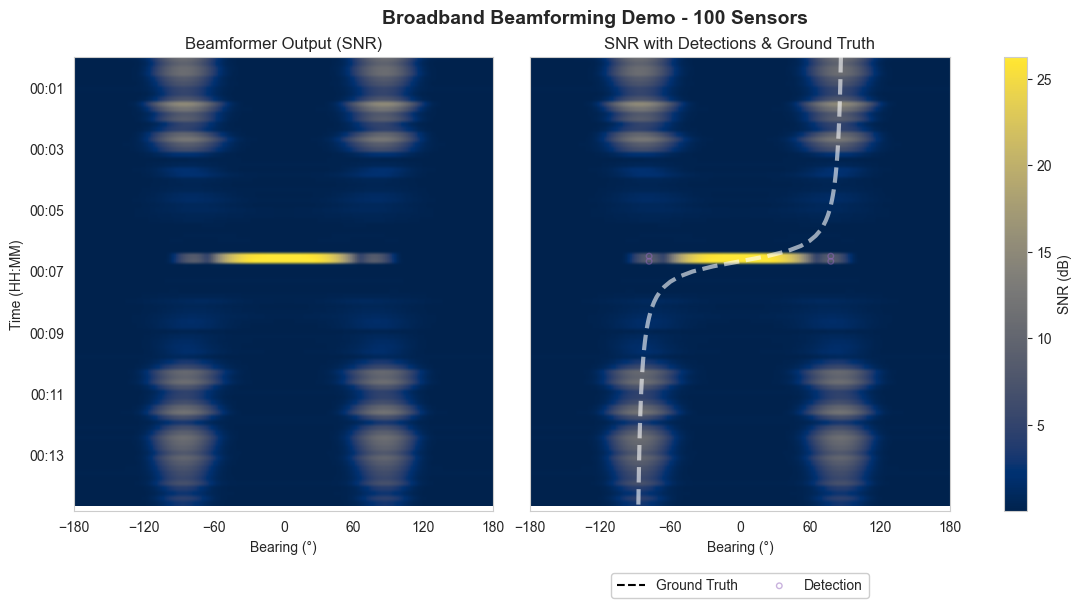

In [70]:
fig1, axs = plt.subplots(1, 2, figsize=(12, 6), sharey=True, tight_layout=True)

# Left: Raw SNR (exclude last timestep)
plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=[],
    truths=[],
    ax=axs[0],
    add_colorbar=False,
)
axs[0].set_title("Beamformer Output (SNR)")

# Right: SNR with detections and truth (exclude last timestep)
_, im = plotter.plot_snr(
    snr_array=snr_map[:-1],
    timesteps=timesteps[:-1],
    all_detections=detections_for_plotter[:-1],
    truths=[relative_bearing_ground_truth],
    ax=axs[1],
    add_colorbar=False,
)
axs[1].set_ylabel("")
axs[1].set_title("SNR with Detections & Ground Truth")

# Add shared colorbar
fig1.colorbar(im, ax=axs.tolist(), label="SNR (dB)")

plt.suptitle(
    f"Broadband Beamforming Demo - {ARRAY_PARAMS['num_sensors']} Sensors",
    fontsize=14,
    fontweight="bold",
    y=1.02,
)

## 10. Trajectory Visualization

Plot the target and platform paths in Cartesian coordinates to understand the relative geometry.

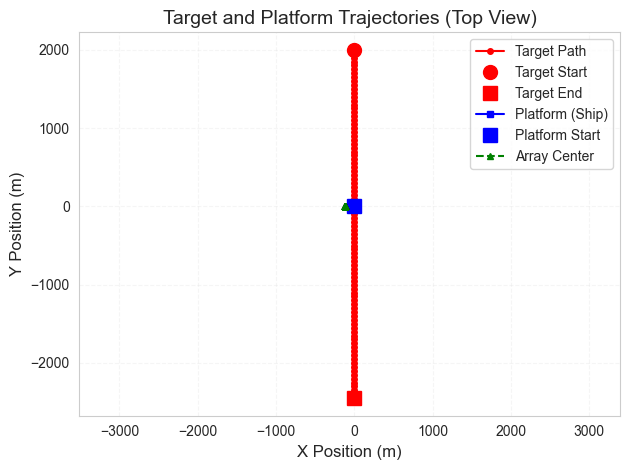

In [71]:
# Plot 2: Trajectories in Cartesian space
fig2, ax_path = plt.subplots()

# Extract positions
target_x = [state.state_vector[0] for state in target_ground_truth]
target_y = [state.state_vector[2] for state in target_ground_truth]

platform_x = []
platform_y = []
array_x = []
array_y = []

for timestamp in timesteps:
    platform_state = platform.get_platform_state_at(timestamp)
    platform_x.append(platform_state.host.state.state_vector[0])
    platform_y.append(platform_state.host.state.state_vector[2])

    array_center = np.mean(platform_state.array.state_vector, axis=1)
    array_x.append(array_center[0])
    array_y.append(array_center[1])

# Plot trajectories
ax_path.plot(target_x, target_y, "r-", label="Target Path", marker="o", markersize=4)
ax_path.plot(target_x[0], target_y[0], "ro", markersize=10, label="Target Start")
ax_path.plot(target_x[-1], target_y[-1], "rs", markersize=10, label="Target End")

ax_path.plot(platform_x, platform_y, "b-", label="Platform (Ship)", marker="s", markersize=4)
ax_path.plot(platform_x[0], platform_y[0], "bs", markersize=10, label="Platform Start")

ax_path.plot(array_x, array_y, "g--", label="Array Center", marker="^", markersize=4)

ax_path.set_xlabel("X Position (m)", fontsize=12)
ax_path.set_ylabel("Y Position (m)", fontsize=12)
ax_path.set_title("Target and Platform Trajectories (Top View)", fontsize=14)
ax_path.legend(loc="best", fontsize=10)
ax_path.grid(True, alpha=0.3)
ax_path.axis("equal")
plt.tight_layout()
plt.show()

## 11. Beamformed SNR at Middle Timestep

Examine the beamformer output at a single timestep to see the bearing resolution and detection performance.

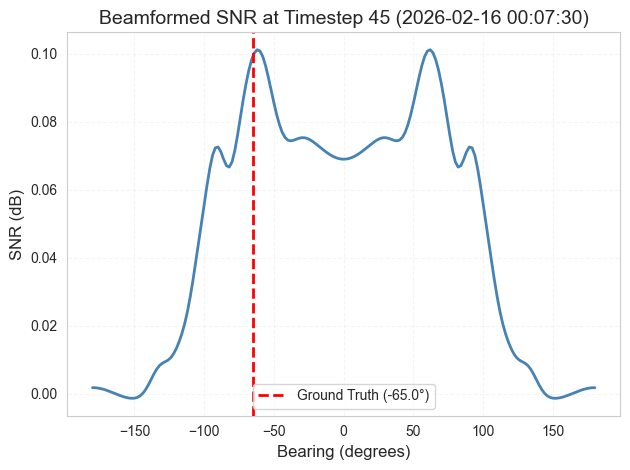

In [72]:
# Plot 3: Beamformed SNR at middle timestep
fig3, ax_middle = plt.subplots()

middle_timestep_idx = SIM_PARAMS["num_steps"] // 2
middle_snr = snr_map[middle_timestep_idx, :]
middle_time = timesteps[middle_timestep_idx]

steering_azimuths_deg = np.rad2deg(STEER_PARAMS["steering_azimuths_rad"])
ax_middle.plot(steering_azimuths_deg, middle_snr, linewidth=2, color="steelblue")
ax_middle.set_xlabel("Bearing (degrees)", fontsize=12)
ax_middle.set_ylabel("SNR (dB)", fontsize=12)
ax_middle.set_title(
    f"Beamformed SNR at Timestep {middle_timestep_idx} ({middle_time})", fontsize=14
)
ax_middle.grid(True, alpha=0.3)

# Mark ground truth bearing
gt_bearing_deg = np.rad2deg(gt_relative_bearings[middle_timestep_idx])
ax_middle.axvline(
    gt_bearing_deg,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Ground Truth ({gt_bearing_deg:.1f}°)",
)

# Mark detections at this timestep if any
if len(detections_for_plotter[middle_timestep_idx]) > 0:
    for det in detections_for_plotter[middle_timestep_idx]:
        det_bearing_deg = np.rad2deg(det.state_vector[0])
        ax_middle.axvline(
            det_bearing_deg,
            color="green",
            linestyle=":",
            linewidth=1.5,
            label=f"Detection ({det_bearing_deg:.1f}°)",
        )

ax_middle.legend(fontsize=10)
plt.tight_layout()
plt.show()